In [1]:
'''SUBJECT POSITIONS'''
#MOana specific
import os, subprocess
print("PID:", os.getpid())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("hostname:", subprocess.run(["hostname"], capture_output=True, text=True).stdout.strip())
print(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout)
#MOANA ONLY
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"
#check for errors
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2


PID: 48297
CUDA_VISIBLE_DEVICES: None
hostname: cf331f7aa4bc
Failed to initialize NVML: Unknown Error



In [5]:
# Cell 0 — CONFIG
import sys, os
from dotenv import load_dotenv
if sys.platform == "win32":
    project_root = Path(r"F:/MScPROJECT_LOCAL")
else:
    _linux_candidates = [Path("/knuckles_drive"), Path("/workspaces/MScPROJECT_LOCAL")]
    for _candidate in _linux_candidates:
        if _candidate.exists():
            project_root = _candidate
            break
    else:
        raise FileNotFoundError(f"None of the known project_root paths exist: {_linux_candidates}")
load_dotenv(project_root / ".env")
case_name = "07_Tropea_cafe"

experiment = "cat_03"

asset_name = f"{case_name}_{experiment}"
from A_Config import set_case
set_case(case_name, experiment)


#These neeed work
case_dir     = project_root / "Data" / case_name
source_dir   = case_dir     / "010_source"
query_dir    = case_dir     / "012_Gemini_outputs"
yolo_masks_dir = case_dir   / "015_YOLO" / experiment
#temp delete sub folder
frames_for_cam_poses = case_dir / "020_frames_for_cam_poses" 
frames_for_recon   = case_dir   / "020_frames_for_recon" / experiment 
VGGT_O_output_dir   = case_dir   /"035_VGGT_O_output"/experiment
predictions_path =  case_dir   /  VGGT_O_output_dir /"predictions.npz" 
CUT3R_output_dir    = case_dir   /"035_CUT3R_output" / experiment

#temp - need to sort out a unified place? no visualisation is justfor me
reg_dir        = case_dir     / "030_Registrations"
csv_path_GPS = case_dir     / "000_GPS_Data" / "GPS_tags.csv"
csv_path_pose = reg_dir     /"camera_poses.csv"


FRAME_NAME_FMT = "{:04d}.jpg"

#TEMP
#This needs to be filed after user input decides on what to analyse
ppt_template = '03_Version_1'

# video loading
# Auto-find the video in 010_source
videos = list(source_dir.glob("*.mp4"))
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")

#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")
#FLAGS
VID_TO_TEXT     = True
TRACKING        = True
FRAME_SELECTION = True
RECON_CAM_POSES = True
RECON_3D_DO      = False
CUT3R_RECON     = True
MEGA_SAM_RECON  = False
VGGT_RECON      = False
VGGT_O_RECON    = True
MULTI_PART_RECON = False
GOOGLE_MAP      = False
PROJECTION_MAP  = True
MAKE_MOVIE      = False

Case    : 07_Tropea_cafe
Video   : VID_20260530_113822990.mp4


In [ ]:
#VGGT OMEGA (sharded) BATCH
# Cell — VGGT-Omega reconstruction across multiple GPUs - run a long sequence thorugh the batch processor.
#it sends in batches of 100 with an overlap of 1 frame for later alignment
if VGGT_O_RECON == True and RECON_3D_DO == True and MULTI_PART_RECON == True:
    import gc, torch
    gc.collect()
    torch.cuda.empty_cache()

    import sys
    sys.path.insert(0, str(project_root / "src"))

    from B_VGGT_O_shards import run_vggt_omega_shards_batched

    recon_out = case_dir / "035_VGGT_O_output" / experiment

    run_vggt_omega_shards_batched(
        image_dir              = str(frames_for_recon),
        output_dir             = str(recon_out),
        checkpoint_path        = str(project_root / "Models" / "vggt-omega" / "checkpoints" / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
        vggt_omega_shards_dir  = str(project_root / "Models" / "vggt-omega-shards"),
        devices                = ["cuda:0", "cuda:1", "cuda:2", "cuda:3"],
        image_resolution       = 512,
        conf_thres             = 20.0,
        max_points             = 0,
        show_cam               = True,
    )
else:
    print("Cell disabled")

    

Cell disabled


In [ ]:
#temp for already solved 
RECON_CAM_POSES = True

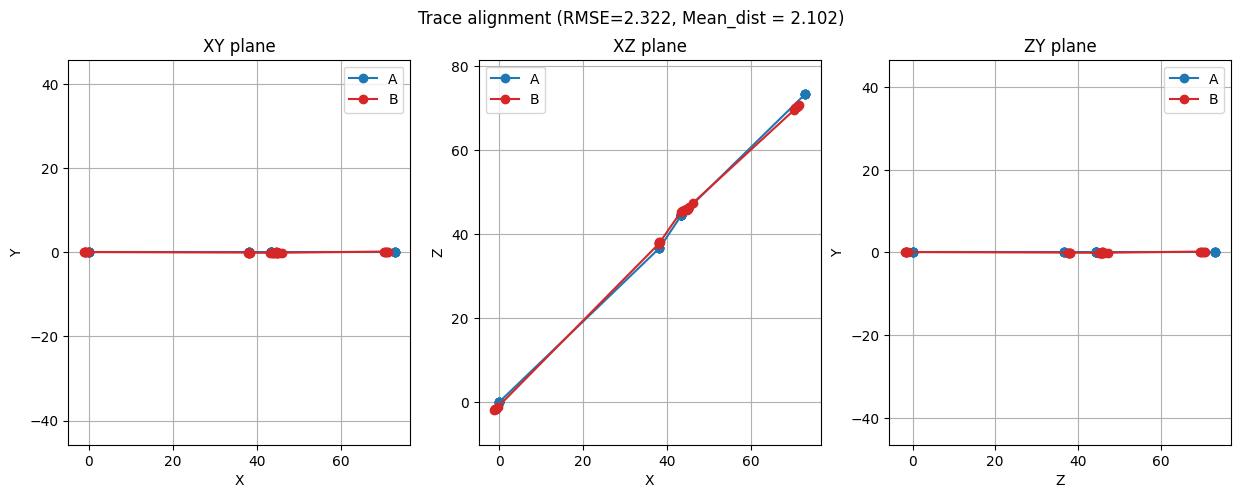

In [3]:
#convert CAMERA POSES from model-world-space into real-world-space (RS formatted at the moment). First cam in the cam pose solve is 000000
if RECON_CAM_POSES == True and VGGT_O_RECON ==True:
    
    #get lat lon positions
    #get transforms to convert other things too
    from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
    cam_poses_realworld_dict, cam_latlons, R, s, t, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, csv_path_pose)
else:
    print("Cell disabled")

In [ ]:
#LOAD THE RECONS
from E_post_recon_processing import Reconstruction
if VGGT_O_RECON == True:
    if MULTI_PART_RECON == True:
        from B_VGGT_O_shards import discover_vggt_omega_shards
        from F_alignments import umeyama_align, recon_to_recon_transform, combine_transforms
        print("A")
        shards = discover_vggt_omega_shards(VGGT_O_output_dir)
        print("B")
        #makes list of recons.
        recons = [
            Reconstruction.load(frames_for_recon, npz_path, FRAME_NAME_FMT, frame_range=(start, end))
            for start, end, npz_path in shards
        ]
        print(f"loaded {len(recons)} recon shards: {[(s, e) for s, e, _ in shards]}")
        multi = True

A
B
loaded 3 recon shards: [(0, 100), (99, 199), (198, 245)]


A
B
loaded 3 recon shards: [(0, 100), (99, 199), (198, 245)]
merging
Subject VGGT-O → real-world: 5 pairs, RMSE = 0.0219 m


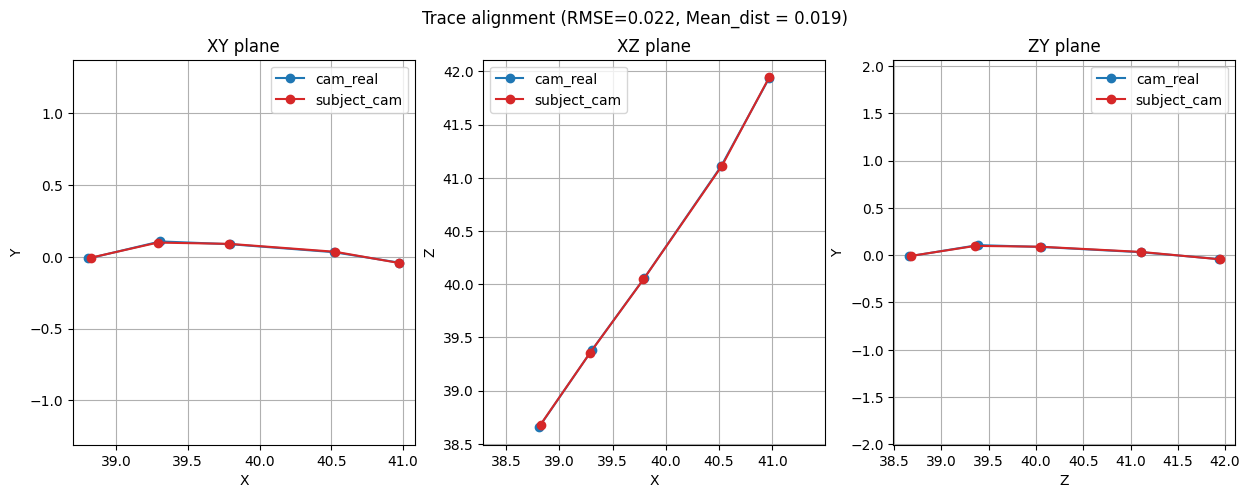

In [ ]:
#MULTI  TRANSFORM MERGE and PLY maker
#processes spatial information about the subject - for report and generates the data needed to map the subject
from E_post_recon_processing import Reconstruction
#Takes the lat and long to do mapping
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
if VGGT_O_RECON == True:
    if MULTI_PART_RECON == True:
        from B_VGGT_O_shards import discover_vggt_omega_shards
        from F_alignments import umeyama_align, recon_to_recon_transform, combine_transforms
        print("A")
        shards = discover_vggt_omega_shards(VGGT_O_output_dir)
        print("B")
        #makes list of recons.
        recons = [
            Reconstruction.load(frames_for_recon, npz_path, FRAME_NAME_FMT, frame_range=(start, end))
            for start, end, npz_path in shards
        ]
        print(f"loaded {len(recons)} recon shards: {[(s, e) for s, e, _ in shards]}")
        multi = True
        
        #transforms to get separate recons to align with each other - save until all transforms are made
        print("merging")
        #get tranform needed to turn first recon from modelspace into real world
        R_mw , s_mw, t_mw  = recon_to_recon_transform(recons[0],cam_poses_realworld_dict)

        merge_xforms = [(R_mw , s_mw, t_mw)]
        
        #use overlapping frames to align the recon shards
        #start with the model to world
        R = R_mw
        s = s_mw
        t = t_mw


           #for point clouds: we don't want the real world
        Rpc = np.eye(3)
        spc = 1
        tpc = 0
        point_cloud_xforms = [(Rpc , spc, tpc)]
     
        for i in range(len(recons)):
            #for point cloud rendering
            #rotate, scale and transform the points into real-world space and then transform to the very first camera's position
            centre = recons[i].VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , R=R, t=t, s=s, multi=multi, centre_to_cam00=t_mw)
            #load up same frame's points from the 2 recons that overlap
            #now to prepare the transform for the next shard
            if i+1 <len(recons): 
                #EXTRINSICS of the one that's already been done
                #rotation+translation of final frame into model space when i =0, this is cam 0
                extr = recons[i].preds["extrinsic"][-1].cpu().numpy()      #(3,4) model->cam matrix 
                R_cm = extr[:3, :3].T                               #cam-to-model rotation 
                t_cm= -R_cm @ extr[:3, 3]                   #cam to model translation

                #extrinsics of the one to be done are all 00000, so we don't need it.


                #but we do need scale: 
                #  fx/fy ratios they won't match - since VGGT normalises
                intr_to   = recons[i].preds["intrinsic"][-1].cpu().numpy()   
                intr_from = recons[i+1].preds["intrinsic"][0].cpu().numpy()  
                fx_ratio = intr_from[0, 0] / intr_to[0, 0]
                fy_ratio = intr_from[1, 1] / intr_to[1, 1]
                if abs(fx_ratio - fy_ratio) / min(fx_ratio, fy_ratio) > 0.05:
                    print(f"WARNING junction {i}->{i+1}: fx/fy scale ratios disagree by >5% "
                          f"(fx={fx_ratio:.4f}, fy={fy_ratio:.4f}) - inspect this shared frame")
                s_cm = np.sqrt(fx_ratio * fy_ratio)   #geometric mean = least-squares combiner in log-space for a multiplicative factor
             
                #then merge into 1 set of transforms
                R,s,t = combine_transforms(R_cm, s_cm, t_cm, R, s, t) 
                #point cloud transformers
                Rpc, spc, tpc = combine_transforms(R_cm, s_cm, t_cm, Rpc, spc, tpc) 
                merge_xforms.append((R,s,t))
                point_cloud_xforms.append((Rpc, spc, tpc)) 

Subject VGGT-O → real-world: 5 pairs, RMSE = 0.0219 m
shard 0: GPS-only scale (model_0 -> world) = 16.1012
Subject VGGT-O → real-world: 5 pairs, RMSE = 0.0458 m
shard 1: GPS-only scale (model_1 -> world) = 17.5658
Subject VGGT-O → real-world: 3 pairs, RMSE = 0.0158 m
shard 2: GPS-only scale (model_2 -> world) = 16.6186

junction 0->1:
  intrinsics ratio : 1.0627
  depth-based fit  : 1.0521
  GPS-implied      : 1.0910

junction 1->2:
  intrinsics ratio : 0.9181
  depth-based fit  : 0.8109
  GPS-implied      : 0.9461



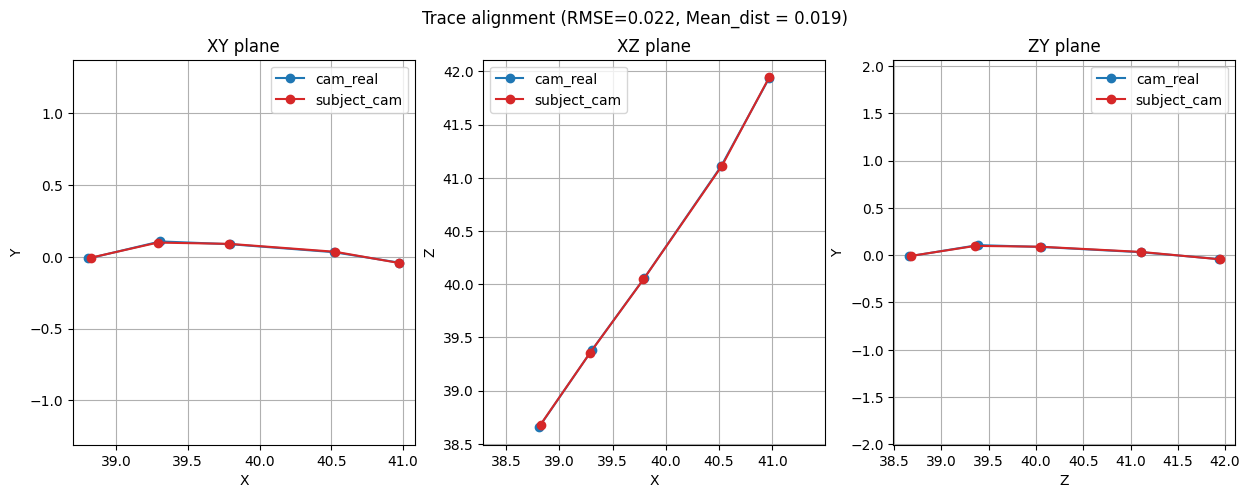

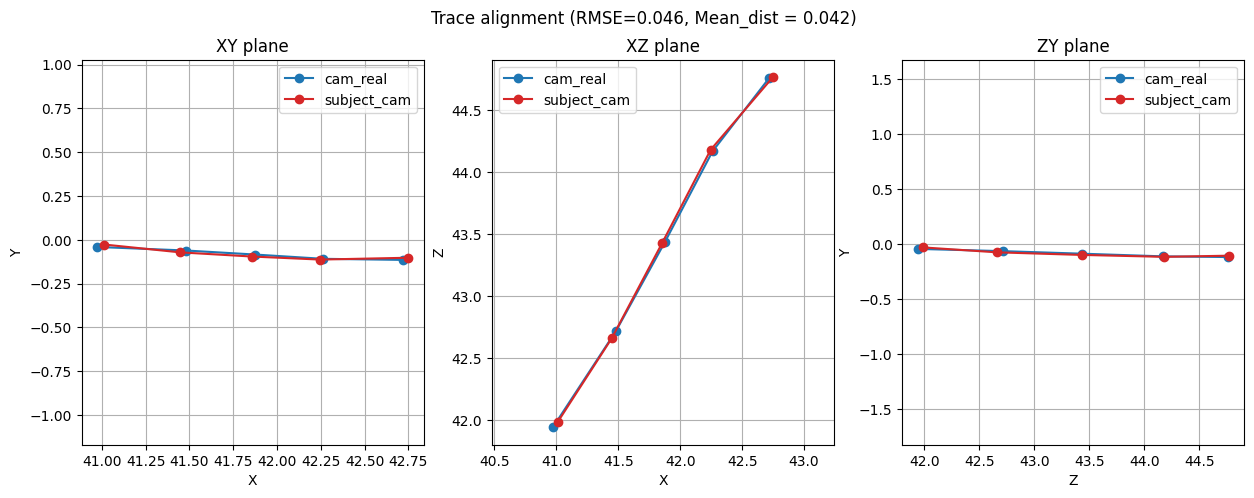

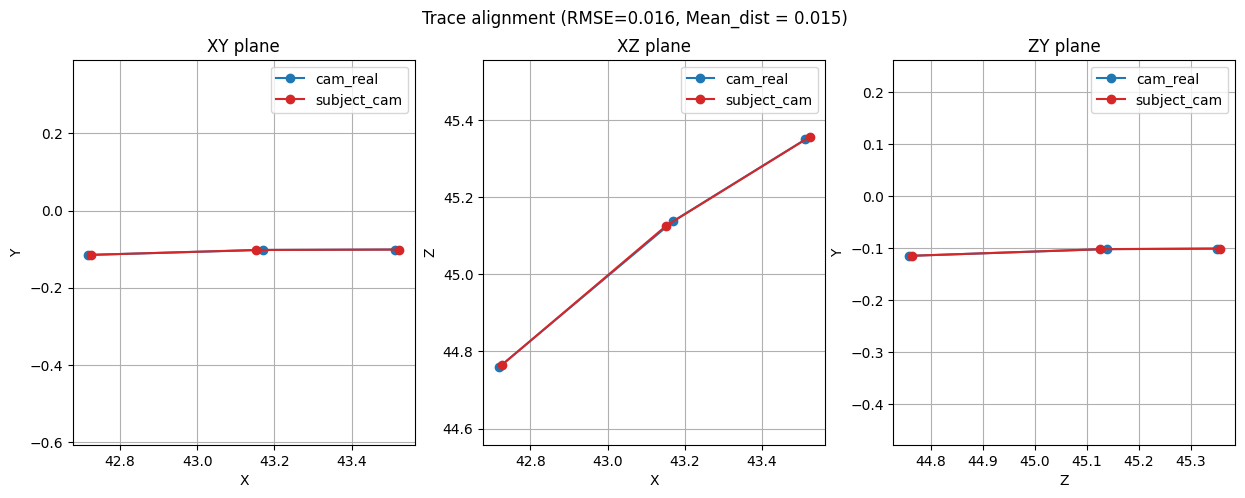

In [ ]:
#SCALE CROSS-CHECK: three independent estimates of each junction's model_(i+1)->model_i scale
#1) intrinsics fx/fy ratio (already used in the merge cell above)
#2) depth-based least-squares fit on the shared frame's confident points (the original approach)
#3) GPS-only: register EACH shard independently against cam_poses_realworld_dict, then take the
#   RATIO of the two shards' own GPS-derived scales. Rotation from this per-shard GPS fit is NOT
#   trustworthy (Z-roll degeneracy on a near-straight path - why we don't use it for R,t) but SCALE
#   from position-magnitude matching doesn't share that degeneracy, so it's a genuinely independent
#   third number, using zero pixel depth and zero shared-frame intrinsics.
from F_alignments import recon_to_recon_transform

#independent GPS-only registration, per shard - only s_gps[i] is trustworthy from this, not R/t
s_gps = []
for i in range(len(recons)):
    _, s_gps_i, _ = recon_to_recon_transform(recons[i], cam_poses_realworld_dict)
    s_gps.append(s_gps_i)
    print(f"shard {i}: GPS-only scale (model_{i} -> world) = {s_gps_i:.4f}")

print()
for i in range(len(recons) - 1):
    #--- 1) intrinsics fx/fy ratio, same formula as the merge cell ---
    intr_to   = recons[i].preds["intrinsic"][-1].cpu().numpy()
    intr_from = recons[i+1].preds["intrinsic"][0].cpu().numpy()
    fx_ratio = intr_from[0, 0] / intr_to[0, 0]
    fy_ratio = intr_from[1, 1] / intr_to[1, 1]
    s_intrinsics = np.sqrt(fx_ratio * fy_ratio)

    #--- 2) depth-based least-squares fit on the shared frame's confident points ---
    extr = recons[i].preds["extrinsic"][-1].cpu().numpy()
    R_cm = extr[:3, :3].T
    t_cm = -R_cm @ extr[:3, 3]
    conf_to   = recons[i].preds["depth_conf"][-1].reshape(-1).cpu().numpy()
    conf_from = recons[i+1].preds["depth_conf"][0].reshape(-1).cpu().numpy()
    valid = (conf_to > 1.5) & (conf_from > 1.5)
    points_to   = recons[i].preds["model_points_from_depth"][-1].reshape(-1, 3).cpu().numpy()[valid]
    points_from = recons[i+1].preds["model_points_from_depth"][0].reshape(-1, 3).cpu().numpy()[valid]
    u = (R_cm @ points_from.T).T
    v = points_to - t_cm
    s_depth = np.sum(u * v) / np.sum(u * u)

    #--- 3) GPS-implied junction scale: ratio of the two shards' independent GPS-derived scales ---
    s_gps_junction = s_gps[i + 1] / s_gps[i]

    print(f"junction {i}->{i+1}:")
    print(f"  intrinsics ratio : {s_intrinsics:.4f}")
    print(f"  depth-based fit  : {s_depth:.4f}")
    print(f"  GPS-implied      : {s_gps_junction:.4f}")
    print()


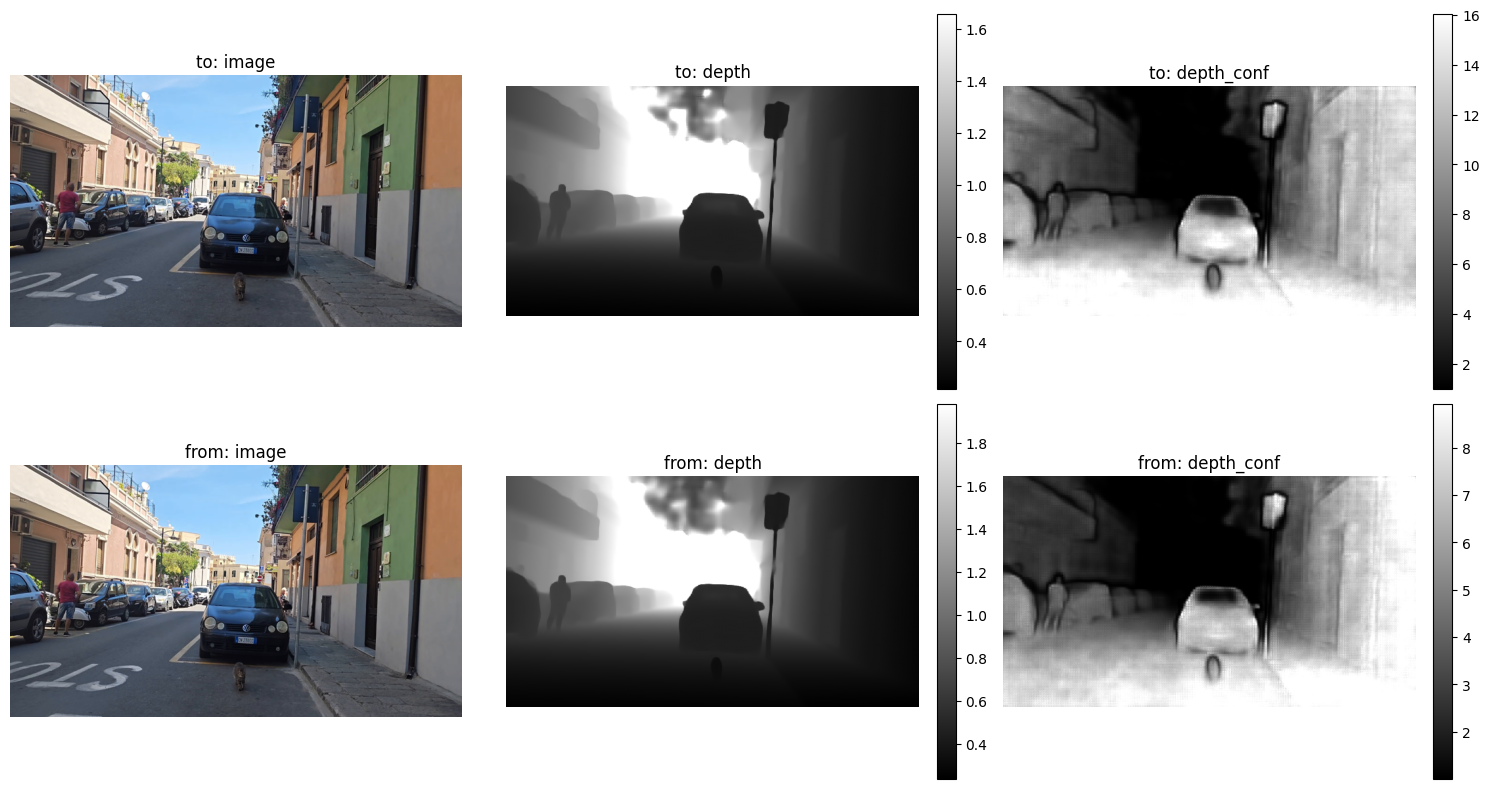

max abs image diff: 0.0


In [ ]:
#QUICK LOOK AT DEPTH MAPS
import matplotlib.pyplot as plt

row_to, row_from = -1, 0   # recons[i]'s last frame vs recons[i+1]'s first frame

img_to    = recons[1].preds["images"][row_to].permute(1, 2, 0).cpu().numpy()
img_from  = recons[2].preds["images"][row_from].permute(1, 2, 0).cpu().numpy()
depth_to    = recons[1].preds["depth"][row_to].cpu().numpy()
depth_from  = recons[2].preds["depth"][row_from].cpu().numpy()
conf_to     = recons[1].preds["depth_conf"][row_to].cpu().numpy()
conf_from   = recons[2].preds["depth_conf"][row_from].cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, im, title in zip(
    axes.ravel(),
    [img_to, depth_to, conf_to, img_from, depth_from, conf_from],
    ["to: image", "to: depth", "to: depth_conf", "from: image", "from: depth", "from: depth_conf"],
):
    if im.ndim == 3:
        shown = ax.imshow(im)
    else:
        # robust vmin/vmax (1st/99th percentile) so a few outlier values (e.g. sky)
        # don't crush the rest of the range into near-black
        vmin, vmax = np.percentile(im, [0, 90])
        shown = ax.imshow(im, cmap="gray", vmin=vmin, vmax=vmax)
        fig.colorbar(shown, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("max abs image diff:", (img_to - img_from).abs().max() if hasattr(img_to, "abs") else abs(img_to - img_from).max())


/tmp/ipykernel_1778183/1025009523.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


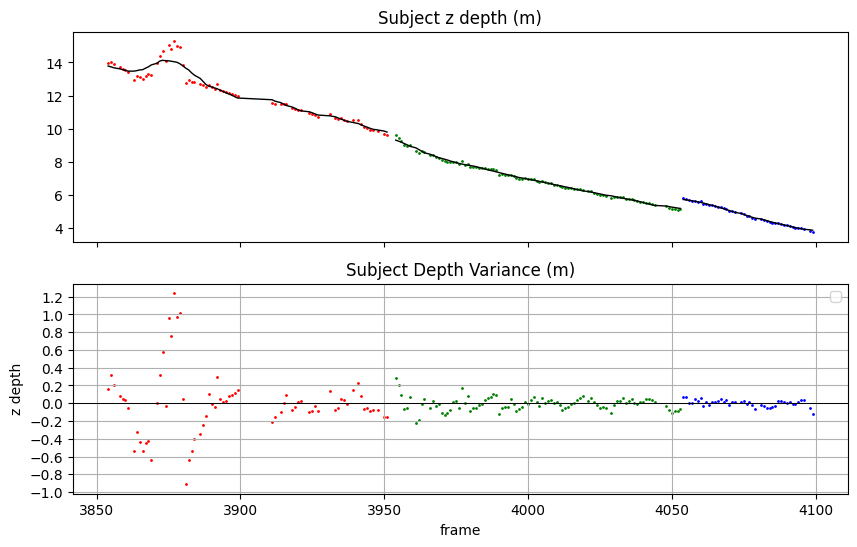

In [ ]:
#POSITIONAL ANALYSIS - UNTRANSFORMED DEPTH
from scipy.ndimage import uniform_filter1d
import cv2
from matplotlib.ticker import MultipleLocator
masks_dir = yolo_masks_dir  # or Path("...")

frame_ranges = [
    range(3854, 3954),
    range(3954, 4054),
    range(4054, 4101),
]

#absolute positions
colors = ["red", "green", "blue"]
labels = ["shard 1", "shard 2", "shard 3"]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for idx, ( recon, frame_ids, colour) in enumerate( zip(recons, frame_ranges, colors)):
    depth = recon.preds["depth"][:].cpu().numpy()
    fr, h_d, w_d = depth.shape

    masks_real = np.stack([
        cv2.imread(str(masks_dir / f"{i:04d}.png"), cv2.IMREAD_GRAYSCALE) > 0
        for i in frame_ids
    ])
    masks_shrunk = np.stack([
        cv2.resize(m.astype(np.uint8), (w_d, h_d), interpolation=cv2.INTER_NEAREST).astype(bool)
        for m in masks_real
    ])
    depth_masked = depth * masks_shrunk
    

    #if no mask, need to remove this as I can't do a trend on no mask
    mask_counts = masks_shrunk.sum(axis=(1, 2))
    valid = mask_counts > 0

    x = np.array(frame_ids)[valid]
    depth_av = depth_masked[valid].sum(axis=(1, 2)) / mask_counts[valid]
    y = depth_av.reshape(-1)
    #scale with GPS transform
    y = y * s_gps[idx]
    #MOVING AVERAGE 
    window = 15  # frames -- smaller tracks erratic motion tighter, larger flattens it more
    trend = uniform_filter1d(y, size=window, mode="nearest")
    noise = y - trend
   
    ax1.scatter(x, y, c=colour, s=1, label = labels[idx])

    ax1.plot(x, trend, color="black", linewidth=1, label=f"moving avg (w={window})")
    #ax1.set_ylim(-0.5, 0.5)
    ax1.set_title ( "Subject z depth (m)")
    ax2.scatter(x, noise, s=1, c=colour)
    ax2.axhline(0, color="black", linewidth=0.5)
    #ax2.set_ylim(-0.5, 0.5) 
    ax2.set_title ( "Subject Depth Variance (m)")
    ax2.grid(True)
    ax2.yaxis.set_major_locator(MultipleLocator(0.2))
plt.xlabel("frame")
plt.ylabel("z depth")

plt.legend()
plt.show()


Subject varaince decreases as subject becomes closer to camera.
Once within 12 m, variance is rarelyl greater than 0.2 m.


/tmp/ipykernel_1778183/3499572370.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


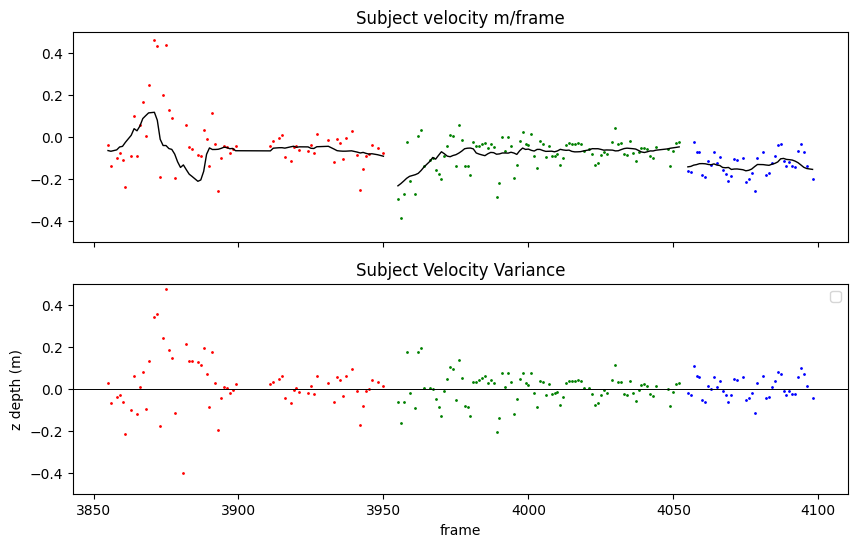

In [ ]:
##change/noise
from scipy.ndimage import uniform_filter1d
colors = ["red", "green", "blue"]
labels = ["shard 1", "shard 2", "shard 3"]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for idx, ( recon, frame_ids, colour) in enumerate( zip(recons, frame_ranges, colors)):
    depth = recon.preds["depth"][:].cpu().numpy()
    fr, h_d, w_d = depth.shape

    masks_real = np.stack([
        cv2.imread(str(masks_dir / f"{i:04d}.png"), cv2.IMREAD_GRAYSCALE) > 0
        for i in frame_ids
    ])
    masks_shrunk = np.stack([
        cv2.resize(m.astype(np.uint8), (w_d, h_d), interpolation=cv2.INTER_NEAREST).astype(bool)
        for m in masks_real
    ])
    #if no mask, need to remove this as I can't do a trend on no mask
    mask_counts = masks_shrunk.sum(axis=(1, 2))
    valid = mask_counts > 0
        
    depth_masked = depth * masks_shrunk
    #depth_av = depth_masked.sum(axis=(1, 2)) / masks_shrunk.sum(axis=(1, 2))
    
    x = np.array(frame_ids)[valid]
    depth_av = depth_masked[valid].sum(axis=(1, 2)) / mask_counts[valid]
    y = depth_av.reshape(-1)
     
    t_0 = x[:-2]
    t_2 = x[2:]
    d_0 = depth_av[:-2]
    d_2 = depth_av[2:]
    delta_t = (t_2 - t_0) / 2
    delta_p = (d_2 - d_0) / 2 
    delta_p = delta_p / depth_av[0] # normalise
    vel_p = delta_p / delta_t
    y = vel_p.reshape(-1)
    #scale with GPS scaling
    y = y * s_gps[idx]
    x = x[1:-1]#trim to fit   


    #MOVING AVERAGE 
    window = 15  # frames -- smaller tracks erratic motion tighter, larger flattens it more
    trend = uniform_filter1d(y, size=window, mode="nearest")
    noise = y - trend
    
    ax1.scatter(x, y, c=colour, s=1, label = labels[idx])
    ax1.plot(x, trend, color="black", linewidth=1, label=f"moving avg (w={window})")
    ax1.set_ylim(-0.5, 0.5)
    ax1.set_title ( "Subject velocity m/frame")
    ax2.scatter(x, noise, s=1, c=colour)
    ax2.axhline(0, color="black", linewidth=0.5)
    ax2.set_ylim(-0.5, 0.5) 
    ax2.set_title ( "Subject Velocity Variance")
plt.xlabel("frame")
plt.ylabel("z depth (m)")

plt.legend()
plt.show()

In [ ]:
#SUBJECT ANALYSIS
from Q_subject_analysis import subject_to_metric_and_gps_space

sub_rw_dicts = {
    i: subject_to_metric_and_gps_space(
        recons[i],
        masks_dir=str(yolo_masks_dir),
        lat_0=lat_0, lon_0=lon_0,
       
        R_mw=merge_xforms[i][0], s_mw=merge_xforms[i][1], t_mw=merge_xforms[i][2],
    )
    for i in range(len(recons))
}
# sub_rw_dicts[i] == (sub_latlon_i, sub_pos_i, sub_pos_real_dict_i)

[ WARN:0@2668.647] global loadsave.cpp:278 findDecoder imread_('/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/015_YOLO/cat_04/3853.png'): can't open/read file: check file path/integrity


In [2]:
#graph postions 2d
from matplotlib import pyplot as plt
# sub_rw_dicts[i] == (sub_latlon_i, sub_pos_i, sub_pos_real_dict_i)

y_0 = sub_rw_dicts[0][1][:,2]
x_0 = sub_rw_dicts[0][1][:,0]
y_1 = sub_rw_dicts[1][1][:,2]
x_1 = sub_rw_dicts[1][1][:,0]
y_2 = sub_rw_dicts[2][1][:,2]
x_2 = sub_rw_dicts[2][1][:,0]
fig, ax = plt.subplots()
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

ax.scatter(x_0, y_0, c=np.arange(len(x_0)), cmap="Reds")
ax.scatter(x_1, y_1, c=np.arange(len(x_1)), cmap="Greens")
ax.scatter(x_2, y_2, c=np.arange(len(x_2)), cmap="Blues")

ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
ax.set_xlabel("east/west (m)")
ax.set_ylabel("north/south (m)")
ax.set_title("Subject position by shard (color = time)")




NameError: name 'sub_rw_dicts' is not defined

shards 0 & 1: 1 overlapping frame(s)
  frame 3954: shard0=[44.39989752  0.54900801 46.47814974]  shard1=[42.16374421  0.14295058 43.54218347]  dist=3.713 m
shards 1 & 2: 1 overlapping frame(s)
  frame 4053: shard1=[45.85990968  0.80860932 48.06366655]  shard2=[45.27125873  0.71501356 47.44460329]  dist=0.859 m


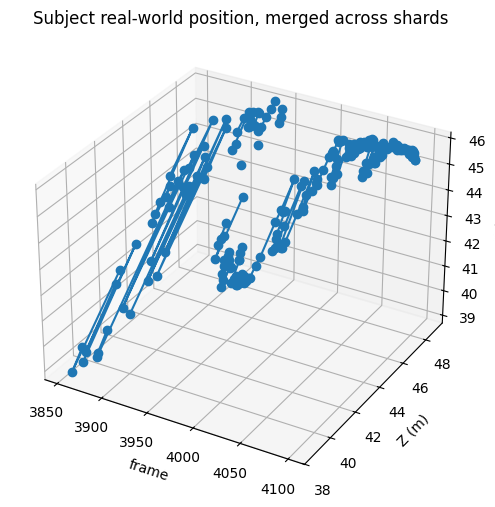

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - registers the 3d projection
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations


def merge_pos(*sub_pos_real_dicts):
    # check every pair of shards for frame numbers they both have a subject position for,
    # and how far apart their independent estimates land in real-world metres
    for (i, a), (j, b) in combinations(enumerate(sub_pos_real_dicts), 2):
        shared_keys = sorted(set(a) & set(b))
        if not shared_keys:
            continue
        print(f"shards {i} & {j}: {len(shared_keys)} overlapping frame(s)")
        for k in shared_keys:
            pa, pb = a[k], b[k]
            dist = np.linalg.norm(pa - pb)  # distance between points - the mismatch in modelling
            print(f"  frame {k}: shard{i}={pa}  shard{j}={pb}  dist={dist:.3f} m")

    # merge - later shard wins on collision (same behaviour as before, now with visibility into what's being dropped)
    sub_pos_real_dict_all = {}
    for d in sub_pos_real_dicts:
        sub_pos_real_dict_all.update(d)
    return sub_pos_real_dict_all


def graph_positions_3D(positions_dict):
    keys = np.array(sorted(positions_dict.keys()))
    pos  = np.array([positions_dict[k] for k in keys])   # (N, 3)
    fig = plt.figure(figsize=(14, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(keys, pos[:, 2], pos[:, 0], "o-")
    ax.set_xlabel("frame")
    ax.set_ylabel("Z (m)")
    ax.set_zlabel("X (m)")
    ax.set_title("Subject real-world position, merged across shards")
    plt.show()

#unpack resutls to get the postoins dicts
sub_pos_real_dicts = [v[2] for v in sub_rw_dicts.values()]
sub_pos_real_dict_all = merge_pos(*sub_pos_real_dicts)
graph_positions_3D(sub_pos_real_dict_all)

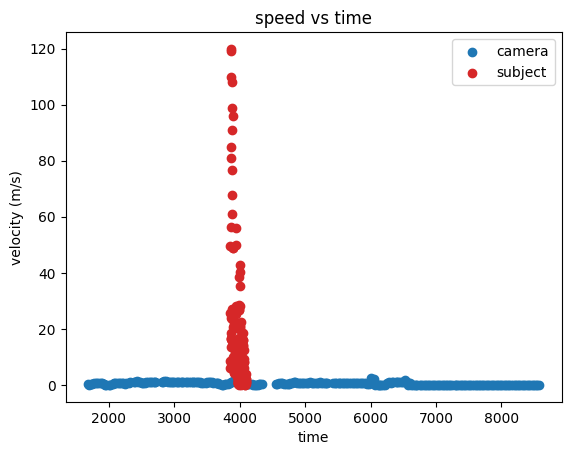

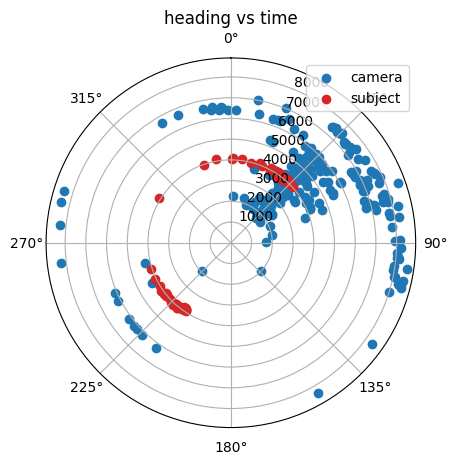

In [ ]:
##Graphing and analysis of camera  TEMPORARY in here
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
fps = 30.07 #temp!
#metrics = speed_direction(cam_poses_realworld_dict, fps)
#sub_metrics = speed_direction(sub_pos_real_dict_0  , fps)
group_metrics = speed_direction((cam_poses_realworld_dict,sub_pos_real_dict_all),
                                 fps,                                 
                                 )



In [6]:
#LOAD VGGT_O recon for further processing
if MULTI_PART_RECON == False:
    from E_post_recon_processing import Reconstruction
    recon = Reconstruction.load(frames_for_recon, predictions_path, FRAME_NAME_FMT)
else:
    print("Cell Disabled")

In [ ]:
print( recon.preds["extrinsic"][9] )
ext = recon.preds["extrinsic"][9].clone()
ext[1, 3] += 1/16   # lift camera 1m (1/16 scale)


print(ext)

tensor([[ 0.9889,  0.0018, -0.1485,  0.0066],
        [ 0.0030,  0.9995,  0.0325, -0.0043],
        [ 0.1485, -0.0326,  0.9884, -0.1311]])
tensor([[ 0.9889,  0.0018, -0.1485,  0.0066],
        [ 0.0030,  0.9995,  0.0325,  0.0582],
        [ 0.1485, -0.0326,  0.9884, -0.1311]])


In [29]:
import torch
ext9 = recon.preds["extrinsic"][9]
Rx = torch.tensor([[1., 0., 0.],
                   [0., 0., -1.],
                   [0., 1., 0.]], dtype=ext9.dtype, device=ext9.device)

ext = Rx @ ext9        # pitch 90° down, camera stays where cam 9 was
ext[2, 3] += 20/16     # lift 10m (up is -z now that the view axis points down)
ext[1, 3] += 5/16      # forward 5m along cam 9's original heading



In [ ]:
if PROJECTION_MAP == True:
    #2D projection mapping of subject to a selected view
    #Controls can be changed to do this:

    #1) use an image as base, project other image's masked content onto this image (main, masks, no new view)
    #2) define camera, reproject one frame at a time (no main idx, no masks, new view) 
    #3) composites - instead of giving [frame,frame] give [[frames]] that's going to merge the frames into 1
    
    from E_post_recon_processing import Reconstruction
    from P_projection_mapping import projection_mapping_sequence
    from B_video_processing import available_frames
    #Use this to project every frame in the recon
    extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
    print(extra_indices)

    subject_positions = projection_mapping_sequence(
        
        recon         = recon,
        #main_idx      = 3900,

        #extra_indices = range (3854,4397),
        #other syntax  [400,4027, 4052, 4065],
        #every file in recon
        extra_indices = [extra_indices],
        
        #masks_dir     = str(yolo_masks_dir),
        #point_cloud_xforms = point_cloud_xforms,
        #new_view = recons[0].preds["extrinsic"][0] the cat 6 test
        new_view = ext ,
        confidence_threshold = 2

       )
else:
    print("Cell disabled")

[3854, 3860, 3866, 3872, 3878, 3884, 3890, 3893, 3902, 3908, 3914, 3920, 3924, 3932, 3938, 3944, 3950, 3956, 3962, 3968, 3974, 3980, 3986, 3992, 3998, 4004, 4010, 4016, 4022, 4028, 4034, 4040, 4046, 4052, 4058, 4064, 4070, 4076, 4082, 4088, 4094, 4100, 4106, 4112, 4118, 4124, 4130, 4136, 4142, 4148, 4154, 4160, 4166, 4172, 4178, 4184, 4190, 4196, 4202, 4208, 4214, 4220, 4226, 4232, 4238, 4244, 4250, 4256, 4262, 4268, 4274, 4280, 4286, 4292, 4298, 4304, 4310, 4316, 4322, 4328, 4334, 4337, 4343, 4349, 4358, 4361, 4373, 4379, 4382, 4388, 4394, 4397]
[3854, 3860, 3866, 3872, 3878, 3884, 3890, 3893, 3902, 3908, 3914, 3920, 3924, 3932, 3938, 3944, 3950, 3956, 3962, 3968, 3974, 3980, 3986, 3992, 3998, 4004, 4010, 4016, 4022, 4028, 4034, 4040, 4046, 4052, 4058, 4064, 4070, 4076, 4082, 4088, 4094, 4100, 4106, 4112, 4118, 4124, 4130, 4136, 4142, 4148, 4154, 4160, 4166, 4172, 4178, 4184, 4190, 4196, 4202, 4208, 4214, 4220, 4226, 4232, 4238, 4244, 4250, 4256, 4262, 4268, 4274, 4280, 4286, 4292, 42

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:
from U_rendering import basic_point_cloud_render
#double way to get vggt and cut3r
if VGGT_O_RECON ==True:
    visualisation_dir = case_dir   /  VGGT_O_output_dir 
    model = "VGGT_O"
   

    ply_dir = visualisation_dir / "ply"
    print(ply_dir)
    basic_point_cloud_render(
        ply_dir, model    )
    # report metric name = render name, one row per output asset (path relative to
    


/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_04/ply
/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/PC_render_frames_VGGT_O


KeyboardInterrupt: 